# Happiness, GDP, and Smoking: A Cross-Country Analysis

Understanding the factors that influence happiness is a key topic in economics, sociology, and data science. With the availability of large-scale international datasets, it has become possible to quantitatively analyze how different economic and lifestyle indicators relate to subjective well-being across countries.

This project explores the relationship between happiness levels, GDP per capita, and smoking prevalence. GDP per capita serves as an indicator of economic development, while smoking prevalence represents a lifestyle and public health factor. Happiness is measured using the World Happiness Report index.

**Primary year of analysis: 2022.** A secondary comparison with 2020 (a COVID-19 pandemic year) is included to examine whether the pandemic altered these relationships.

**Research questions:**
1. Do wealthier countries report higher happiness?
2. Does smoking prevalence relate to happiness or GDP?
3. Did the COVID-19 pandemic (2020) change these relationships?


## 1. Data Preparation and Preprocessing

Three datasets were used in this analysis:
- **GDP per capita** — World Bank World Development Indicators (wide format, years as columns)
- **Smoking prevalence** — WHO age-standardized tobacco use among adults 15+ (available for 2020 and 2022)
- **Happiness scores** — World Happiness Report index, 2013–2023

Note: because the smoking dataset only provides data every five years (with 2020 and 2022 being the most recent), the merged dataset contains exactly two time points. **2022 is used as the primary analysis year**; 2020 is retained for a pandemic-era comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
# Load datasets
gdp      = pd.read_csv("GDP PER CAPITA.csv",          sep=";", skiprows=4)
smoking  = pd.read_csv("Smoking world .csv",          sep=";")
happiness = pd.read_csv("World Happiness 2013-2023.csv", sep=";")

print("GDP shape:      ", gdp.shape)
print("Smoking shape:  ", smoking.shape)
print("Happiness shape:", happiness.shape)

GDP shape:       (266, 71)
Smoking shape:   (1050, 4)
Happiness shape: (1523, 8)


The datasets were loaded from CSV files. The GDP dataset is in wide format (years as columns), while the other two use long format (one row per country-year).

In [3]:
# ── GDP: wide → long, keep 2020 & 2022 only ──────────────────────────────────
gdp.columns = gdp.columns.astype(str).str.strip()
gdp = gdp.rename(columns={"Country Name": "country"})
gdp = gdp[["country", "2020", "2022"]]
gdp = gdp.melt(id_vars="country", var_name="year", value_name="gdp")
gdp["year"] = gdp["year"].astype(int)
gdp["gdp"]  = pd.to_numeric(gdp["gdp"], errors="coerce")

gdp.head()

,country,year,gdp
0,Aruba,2020,22759.807175
1,Africa Eastern and Southern,2020,1351.591669
2,Afghanistan,2020,510.787063
3,Africa Western and Central,2020,2030.861659
4,Angola,2020,1759.356199


The GDP dataset was originally in wide format. It was reshaped into long format and filtered to the two analysis years (2020 and 2022).

In [4]:
# ── Smoking: rename, filter to 2020 & 2022 ──────────────────────────────────
smoking.columns = smoking.columns.str.strip()
smoking = smoking.rename(columns={
    "Entity": "country",
    "Year":   "year",
    smoking.columns[3]: "smoking"
})
smoking = smoking[["country", "year", "smoking"]]
smoking["year"]    = smoking["year"].astype(int)
smoking["smoking"] = pd.to_numeric(smoking["smoking"], errors="coerce")
smoking = smoking[smoking["year"].isin([2020, 2022])]

smoking.head()

,country,year,smoking
4,Afghanistan,2020,23.7
5,Afghanistan,2022,22.7
10,Algeria,2020,21.2
11,Algeria,2022,21.2
16,Andorra,2020,36.0


In [5]:
# ── Happiness: fix decimal separator, filter to 2020 & 2022 ────────────────
happiness.columns = happiness.columns.str.strip()
happiness = happiness.rename(columns={"Country": "country", "Year": "year", "Index": "happiness"})
happiness = happiness[["country", "year", "happiness"]]
happiness["year"]      = happiness["year"].astype(int)
happiness["happiness"] = (happiness["happiness"].astype(str)
                           .str.replace(",", ".", regex=False))
happiness["happiness"] = pd.to_numeric(happiness["happiness"], errors="coerce")
happiness = happiness[happiness["year"].isin([2020, 2022])]

happiness.head()

,country,year,happiness
6,Afghanistan,2020,2.567
8,Afghanistan,2022,2.404
16,Albania,2020,4.883
18,Albania,2022,5.199
26,Algeria,2020,5.005


The happiness dataset stored decimal numbers with a comma separator (European convention). These were converted to dot-separated floats before parsing.

In [6]:
# ── Merge all three on (country, year) ──────────────────────────────────────
df = (happiness
      .merge(gdp,     on=["country", "year"], how="inner")
      .merge(smoking, on=["country", "year"], how="inner")
      .dropna())

print(f"Total rows: {len(df)}")
print(df.groupby("year").size().rename("countries"))

Total rows: 248
year
2020    124
2022    124
Name: countries, dtype: int64


The three datasets were merged on country name and year. After dropping rows with missing values, the merged dataset contains **124 countries × 2 years = 248 rows**.

In [7]:
# ── Split into primary (2022) and comparison (2020) subsets ─────────────────
df_2022 = df[df["year"] == 2022].copy().reset_index(drop=True)
df_2020 = df[df["year"] == 2020].copy().reset_index(drop=True)

print("Primary dataset — 2022:")
display(df_2022.describe().round(2))

Primary dataset — 2022:


,year,happiness,gdp,smoking
count,124.0,124.00,124.00,124.00
mean,2022.0,5.58,19176.17,19.32
std,0.0,1.15,25752.34,9.38
min,2022.0,2.40,357.26,3.30
25%,2022.0,4.66,2531.34,11.75
50%,2022.0,5.75,6705.15,19.25
75%,2022.0,6.45,28296.76,24.90
max,2022.0,7.82,123719.66,44.40


**2022 is used as the primary analysis dataset** throughout Sections 2–4. The 2020 dataset is used only in Section 5 (pandemic comparison).

## 2. Exploratory Data Analysis (2022)

This section explores the distributions of and relationships between the three variables using the 2022 dataset.

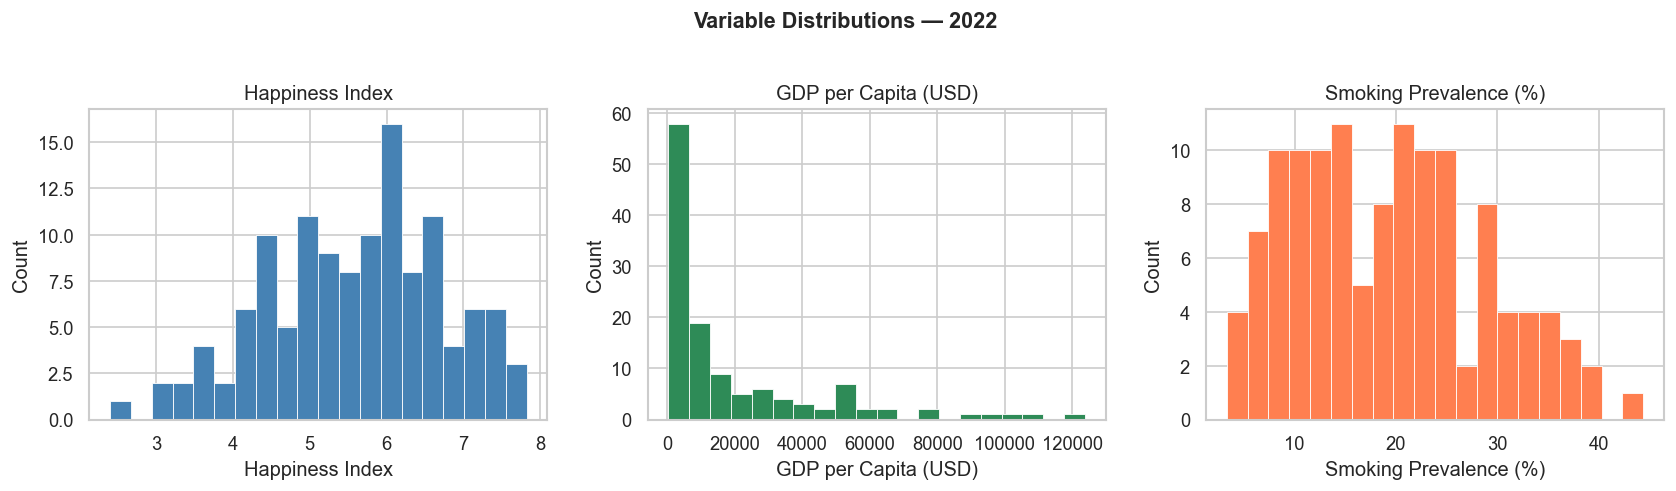

In [8]:
# ── Distributions ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label, color in zip(
        axes,
        ["happiness", "gdp", "smoking"],
        ["Happiness Index", "GDP per Capita (USD)", "Smoking Prevalence (%)"],
        ["steelblue", "seagreen", "coral"]):
    ax.hist(df_2022[col], bins=20, color=color, edgecolor="white", linewidth=0.5)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

plt.suptitle("Variable Distributions — 2022", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

GDP per capita shows a strongly right-skewed distribution, reflecting high inequality between low- and high-income countries. Happiness scores are roughly bell-shaped, while smoking prevalence is more uniformly spread.

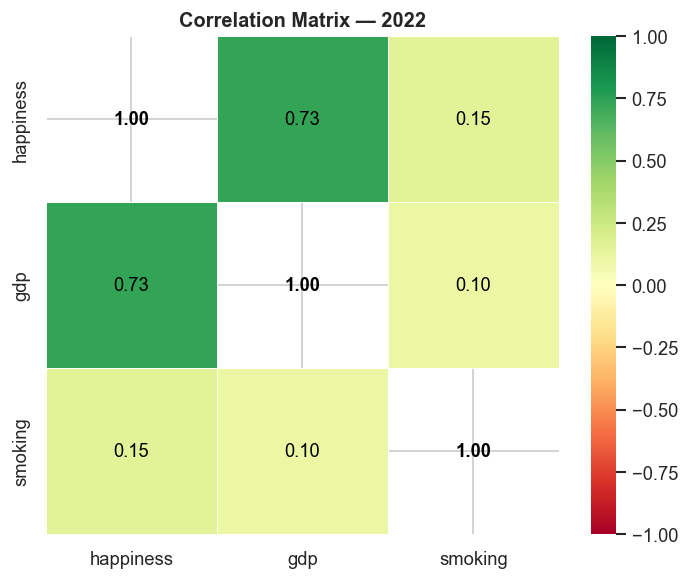

           happiness    gdp  smoking
happiness      1.000  0.733    0.153
gdp            0.733  1.000    0.102
smoking        0.153  0.102    1.000


In [9]:
# ── Correlation matrix (2022 only) ───────────────────────────────────────────
corr = df_2022[["happiness", "gdp", "smoking"]].corr()

mask = np.eye(len(corr), dtype=bool)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=False, cmap="RdYlGn", center=0,
            mask=mask, ax=ax, linewidths=0.5, fmt=".2f",
            vmin=-1, vmax=1)

# Manual diagonal labels
for i in range(len(corr)):
    ax.text(i + 0.5, i + 0.5, "1.00",
            ha="center", va="center", color="black", fontsize=11, fontweight="bold")

# Annotate off-diagonal
for i in range(len(corr)):
    for j in range(len(corr)):
        if i != j:
            ax.text(j + 0.5, i + 0.5, f"{corr.iloc[i, j]:.2f}",
                    ha="center", va="center", color="black", fontsize=11)

ax.set_title("Correlation Matrix — 2022", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(corr.round(3))

The correlation matrix reveals:
- **Happiness ↔ GDP: r = 0.73** — strong positive relationship. Wealthier countries tend to be happier.
- **Happiness ↔ Smoking: r = 0.15** — very weak positive relationship; smoking has little direct association with happiness.
- **GDP ↔ Smoking: r = 0.10** — also very weak; income level alone does not predict smoking rates.

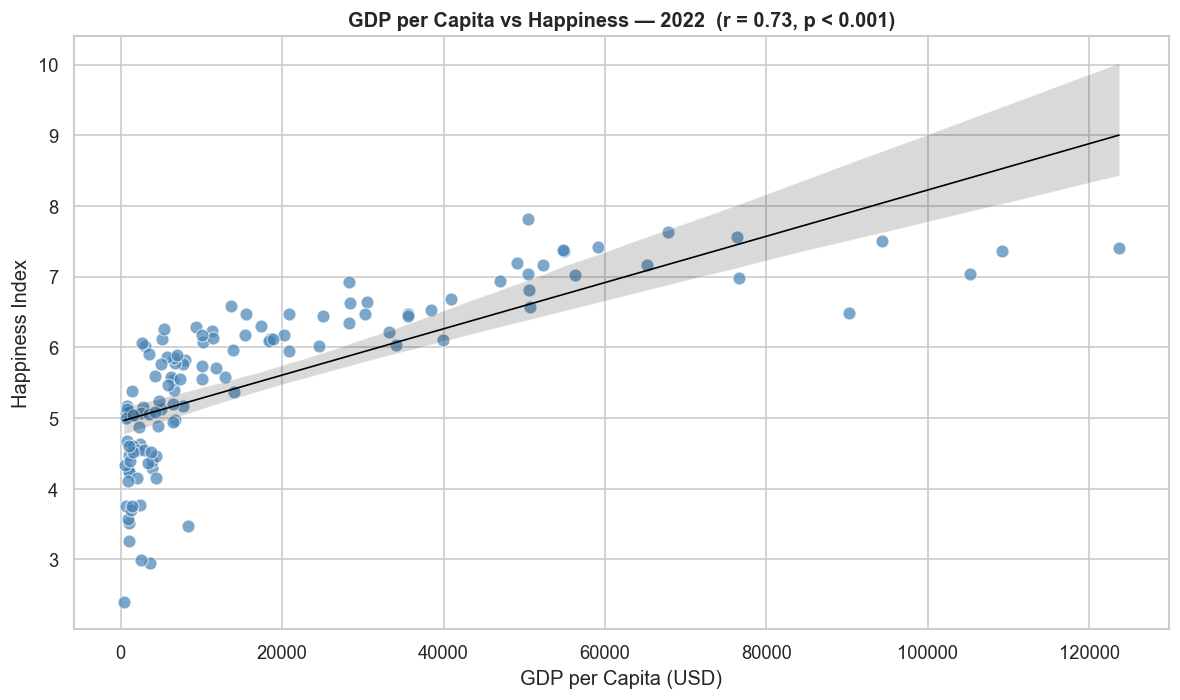

In [10]:
# ── GDP vs Happiness (2022) with regression line ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df_2022, x="gdp", y="happiness",
                color="steelblue", alpha=0.7, s=60, ax=ax)
sns.regplot(data=df_2022, x="gdp", y="happiness",
            scatter=False, color="black", ax=ax, line_kws={"linewidth": 1})

r, p = stats.pearsonr(df_2022["gdp"], df_2022["happiness"])
ax.set_title(f"GDP per Capita vs Happiness — 2022  (r = {r:.2f}, p < 0.001)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("GDP per Capita (USD)")
ax.set_ylabel("Happiness Index")
plt.tight_layout()
plt.show()

The scatter plot confirms a clear positive trend: countries with higher GDP per capita consistently report higher happiness. The relationship is non-linear — gains in happiness diminish at very high income levels, which is consistent with the Easterlin paradox and diminishing marginal utility of income.

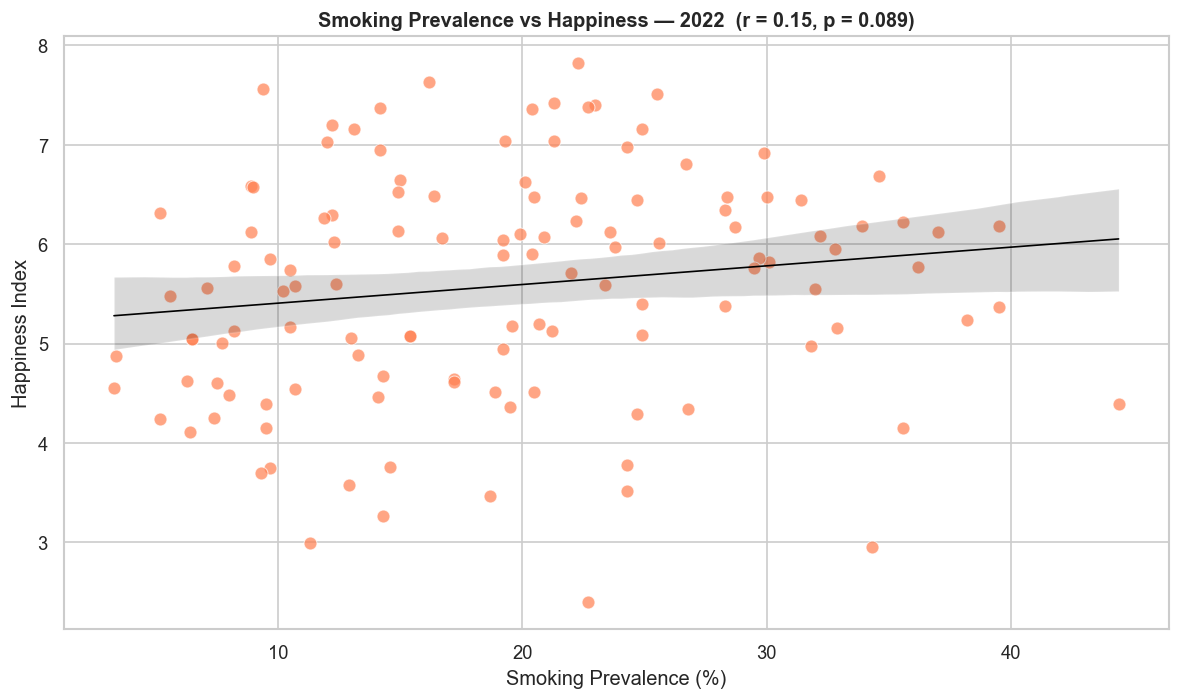

In [11]:
# ── Smoking vs Happiness (2022) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df_2022, x="smoking", y="happiness",
                color="coral", alpha=0.7, s=60, ax=ax)
sns.regplot(data=df_2022, x="smoking", y="happiness",
            scatter=False, color="black", ax=ax, line_kws={"linewidth": 1})

r, p = stats.pearsonr(df_2022["smoking"], df_2022["happiness"])
ax.set_title(f"Smoking Prevalence vs Happiness — 2022  (r = {r:.2f}, p = {p:.3f})",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Smoking Prevalence (%)")
ax.set_ylabel("Happiness Index")
plt.tight_layout()
plt.show()

The relationship between smoking and happiness is weak and not statistically significant at conventional levels. This suggests smoking prevalence is not a meaningful direct predictor of national happiness — cultural, social, and economic factors likely confound any raw association.

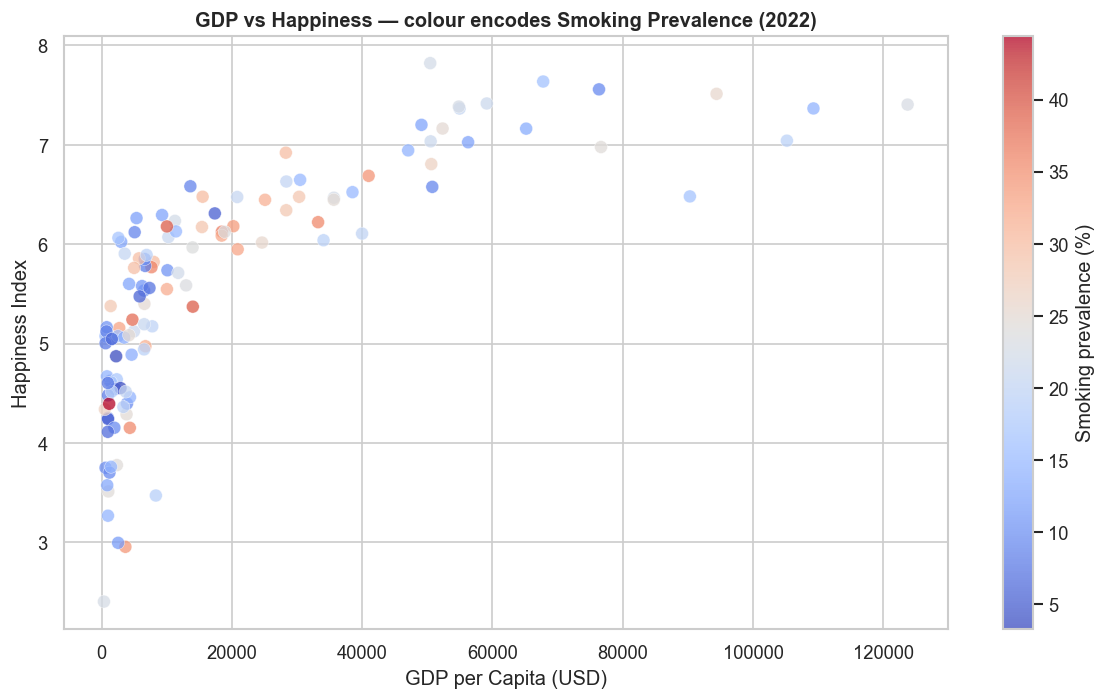

In [12]:
# ── 3-variable plot: GDP vs Happiness, colour = smoking ───────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_2022["gdp"], df_2022["happiness"],
    c=df_2022["smoking"], cmap="coolwarm",
    alpha=0.75, s=60, edgecolors="white", linewidths=0.3
)
plt.colorbar(scatter, ax=ax, label="Smoking prevalence (%)")

ax.set_xlabel("GDP per Capita (USD)")
ax.set_ylabel("Happiness Index")
ax.set_title("GDP vs Happiness — colour encodes Smoking Prevalence (2022)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Encoding smoking as colour reveals that high-smoking countries (red) are spread across all income levels. There is no clear pattern where low-GDP + high-smoking countries cluster at the bottom of the happiness axis, reinforcing that smoking alone does not drive happiness differences.

## 3. Outlier Analysis (2022)

To identify countries that deviate from the expected GDP–happiness relationship, residual analysis was performed using a simple OLS regression of happiness on GDP. Countries are ranked by their residual: positive residuals indicate countries that are **happier than expected** given their income; negative residuals indicate the opposite.

In [13]:
# ── OLS residuals ────────────────────────────────────────────────────────────
from numpy.polynomial import polynomial as P

df_2022 = df_2022.copy()

slope, intercept, r_val, p_val, se = stats.linregress(
    df_2022["gdp"], df_2022["happiness"])

df_2022["predicted"]  = intercept + slope * df_2022["gdp"]
df_2022["residual"]   = df_2022["happiness"] - df_2022["predicted"]

print(f"OLS: happiness = {intercept:.3f} + {slope:.6f} × gdp")
print(f"R²  = {r_val**2:.3f}")

OLS: happiness = 4.953 + 0.000033 × gdp
R²  = 0.537


In [14]:
# ── Happier than expected (positive outliers) ────────────────────────────────
top_happy = df_2022.nlargest(10, "residual")[
    ["country", "happiness", "gdp", "smoking", "residual"]].reset_index(drop=True)
print("Countries happier than expected given their GDP:")
display(top_happy.round(2))

Countries happier than expected given their GDP:


,country,happiness,gdp,smoking,residual
0,Finland,7.82,50440.56,22.3,1.22
1,Costa Rica,6.58,13625.90,8.9,1.18
2,Guatemala,6.26,5358.70,11.9,1.13
3,Czechia,6.92,28282.22,29.9,1.04
4,Brazil,6.29,9281.33,12.2,1.04
5,Uzbekistan,6.06,2578.67,16.7,1.03
6,Romania,6.48,15503.55,30.0,1.02
7,El Salvador,6.12,5074.60,8.9,1.00
8,Honduras,6.02,3003.29,12.3,0.97
9,Kazakhstan,6.23,11255.34,22.2,0.91


These countries score higher on happiness than their GDP alone would predict. Factors such as strong social cohesion, cultural values, or effective social safety nets likely explain the surplus well-being.

In [15]:
# ── Less happy than expected (negative outliers) ─────────────────────────────
bot_happy = df_2022.nsmallest(10, "residual")[
    ["country", "happiness", "gdp", "smoking", "residual"]].reset_index(drop=True)
print("Countries less happy than expected given their GDP:")
display(bot_happy.round(2))

Countries less happy than expected given their GDP:


,country,happiness,gdp,smoking,residual
0,Afghanistan,2.40,357.26,22.7,-2.56
1,Lebanon,2.96,3654.36,34.3,-2.12
2,Zimbabwe,3.00,2536.40,11.3,-2.04
3,Botswana,3.47,8328.71,18.7,-1.76
4,Rwanda,3.27,975.47,14.3,-1.72
5,Luxembourg,7.40,123719.66,23.0,-1.60
6,Lesotho,3.51,1030.13,24.3,-1.48
7,Singapore,6.48,90299.07,16.4,-1.43
8,Sierra Leone,3.57,860.37,12.9,-1.41
9,Ireland,7.04,105190.69,19.3,-1.36


These countries underperform relative to their GDP. High inequality, political instability, or poor governance may suppress happiness despite reasonable income levels.

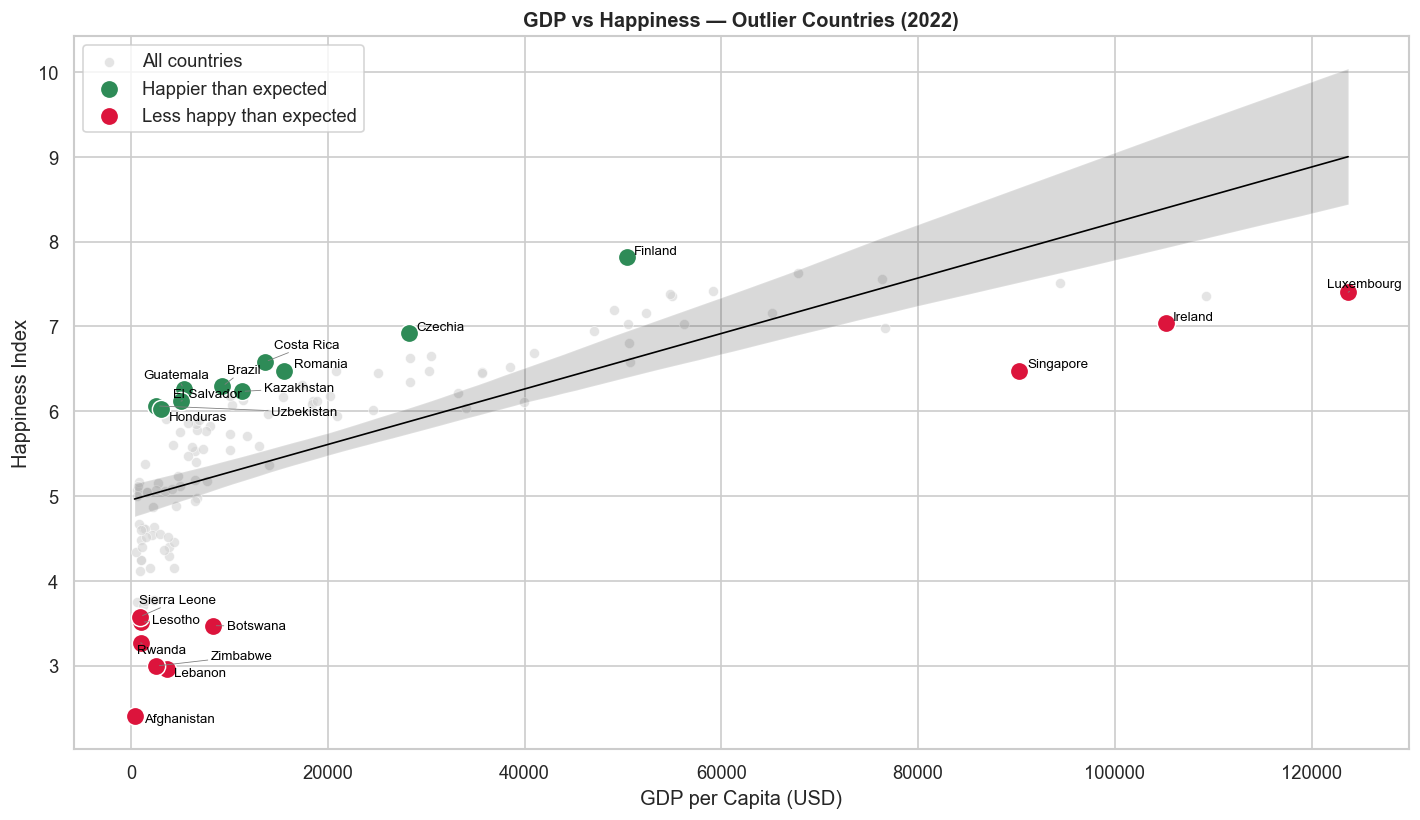

In [16]:
# ── Annotated residual scatter plot ──────────────────────────────────────────
from adjustText import adjust_text

outliers = pd.concat([top_happy, bot_happy])

fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(data=df_2022, x="gdp", y="happiness",
                color="lightgray", alpha=0.6, label="All countries", ax=ax)
sns.regplot(data=df_2022, x="gdp", y="happiness",
            scatter=False, color="black", ax=ax, line_kws={"linewidth": 1})

# Colour by direction
pos = outliers[outliers["residual"] > 0]
neg = outliers[outliers["residual"] < 0]
sns.scatterplot(data=pos, x="gdp", y="happiness",
                color="seagreen", s=120, label="Happier than expected", ax=ax)
sns.scatterplot(data=neg, x="gdp", y="happiness",
                color="crimson",  s=120, label="Less happy than expected", ax=ax)

texts = [ax.text(row["gdp"], row["happiness"], row["country"],
                 fontsize=8, color="black")
         for _, row in outliers.iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_title("GDP vs Happiness — Outlier Countries (2022)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("GDP per Capita (USD)")
ax.set_ylabel("Happiness Index")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Pandemic Comparison: 2020 vs 2022

The year 2020 represents the first year of the COVID-19 pandemic. Comparing correlations and distributions between 2020 and 2022 allows us to ask: **did the pandemic weaken or strengthen the link between GDP and happiness?**

In [17]:
# ── Correlation comparison ───────────────────────────────────────────────────
for year, subset in [("2020 (pandemic)", df_2020), ("2022 (recovery)", df_2022)]:
    r_gdp,  _ = stats.pearsonr(subset["gdp"],     subset["happiness"])
    r_smok, _ = stats.pearsonr(subset["smoking"],  subset["happiness"])
    print(f"{year}:  happiness↔gdp r={r_gdp:.3f}   happiness↔smoking r={r_smok:.3f}")

2020 (pandemic):  happiness↔gdp r=0.739   happiness↔smoking r=0.113
2022 (recovery):  happiness↔gdp r=0.733   happiness↔smoking r=0.153


The GDP–happiness correlation is virtually identical in both years (~0.73–0.74), indicating that the pandemic did not fundamentally reshape the relationship between national income and subjective well-being at the cross-country level. The smoking–happiness correlation remains weak in both periods.

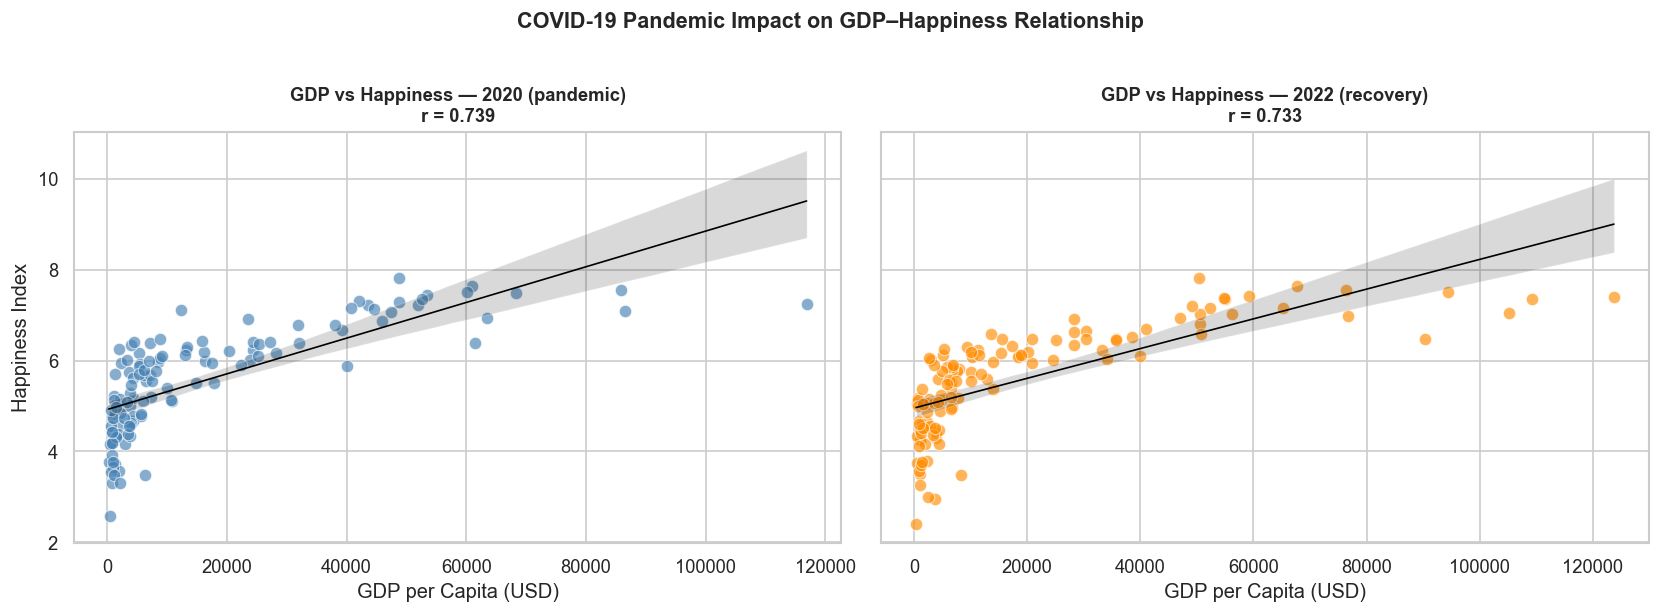

In [18]:
# ── Side-by-side scatter plots: 2020 vs 2022 ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, subset, year, color in zip(
        axes,
        [df_2020, df_2022],
        ["2020 (pandemic)", "2022 (recovery)"],
        ["steelblue", "darkorange"]):
    sns.scatterplot(data=subset, x="gdp", y="happiness",
                    color=color, alpha=0.65, s=55, ax=ax)
    sns.regplot(data=subset, x="gdp", y="happiness",
                scatter=False, color="black", ax=ax, line_kws={"linewidth": 1})
    r, _ = stats.pearsonr(subset["gdp"], subset["happiness"])
    ax.set_title(f"GDP vs Happiness — {year}\nr = {r:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("GDP per Capita (USD)")
    ax.set_ylabel("Happiness Index")

plt.suptitle("COVID-19 Pandemic Impact on GDP–Happiness Relationship",
             y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
# ── Mean happiness change 2020 → 2022 ────────────────────────────────────────
# Compute change for countries present in both years
df_wide = df.pivot_table(index="country", columns="year",
                         values="happiness", aggfunc="first")
df_wide.columns = ["h2020", "h2022"]
df_wide = df_wide.dropna()
df_wide["change"] = df_wide["h2022"] - df_wide["h2020"]

print(f"Countries that became happier 2020→2022: {(df_wide['change'] > 0).sum()}")
print(f"Countries that became less happy:         {(df_wide['change'] < 0).sum()}")
print(f"Mean change: {df_wide['change'].mean():.3f}")
print()
print("Biggest improvements:")
display(df_wide.nlargest(5, "change").round(3))
print("Biggest declines:")
display(df_wide.nsmallest(5, "change").round(3))

Countries that became happier 2020→2022: 66
Countries that became less happy:         55
Mean change: 0.013

Biggest improvements:


,h2020,h2022,change
country,,,
Armenia,4.677,5.399,0.722
Croatia,5.505,6.125,0.620
Liberia,4.558,5.122,0.564
Ukraine,4.561,5.084,0.523
China,5.124,5.585,0.461


Biggest declines:


,h2020,h2022,change
country,,,
Lebanon,4.772,2.955,-1.817
Pakistan,5.693,4.516,-1.177
Benin,5.216,4.623,-0.593
Costa Rica,7.121,6.582,-0.539
Jordan,4.633,4.152,-0.481


Most countries either maintained or improved their happiness scores between the pandemic year and 2022, suggesting a degree of resilience in subjective well-being at the national level.